# The "Sugar Trap" Market Gap Analysis
## Helix CPG Partners - Healthy Snacking opportunity

A snack manufacturer wants to launch a "Healthy Snacking" line. The question: where is the
"Blue Ocean" in the snack aisle - product categories where the market skews high-sugar /
low-protein, leaving room for a high-protein / low-sugar entry?

Using the Open Food Facts database:

1. Ingest and clean the nutritional data (handle missing values, drop impossible values)
2. Turn the messy `categories_tags` strings into a handful of high-level category buckets
3. Plot sugar vs protein and locate the "empty quadrant" (high protein, low sugar)
4. Turn that into a concrete recommendation
5. Bonus: find the most common protein sources in high-protein products
6. Candidate's choice: an opportunity score that ranks categories by how underserved they are

The Open Food Facts CSV is ~9 GB, so we stream it in chunks and keep only the columns and rows
we need, stopping once we have a clean working subset. The full file is never held in memory.

## Setup

In [ ]:
%pip install -q pyarrow  # noqa

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 60)

## 1. Ingest and clean

We pull the Open Food Facts export and read it in chunks. For each chunk we keep only the
nutrition columns we care about, drop rows missing a product name / sugar / protein value, and
discard biologically impossible values (a per-100g nutrient cannot exceed 100 g). We stop once
we have collected `MAX_ROWS` clean rows - a manageable subset as the brief recommends.

In [ ]:
URL = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"
LOCAL = "data/raw/openfoodfacts.csv.gz"   # used if you downloaded it yourself
MAX_ROWS = 500_000                         # size of the clean working subset

USECOLS = [
    "code", "product_name", "categories_tags",
    "sugars_100g", "proteins_100g", "fiber_100g", "fat_100g",
    "salt_100g", "energy-kcal_100g", "ingredients_text",
]
NUTRIENTS = ["sugars_100g", "proteins_100g", "fiber_100g", "fat_100g", "salt_100g"]

# Read straight from the URL if the local file is not present (works in Colab).
source = LOCAL if os.path.exists(LOCAL) else URL
print("Reading from:", source)

def clean_chunk(df):
    df = df.dropna(subset=["product_name", "sugars_100g", "proteins_100g"])
    for c in NUTRIENTS + ["energy-kcal_100g"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # Per-100g nutrients must sit in [0, 100]; energy in a sane [0, 900] kcal range.
    for c in NUTRIENTS:
        df = df[(df[c] >= 0) & (df[c] <= 100)]
    df = df[(df["energy-kcal_100g"].isna()) | (df["energy-kcal_100g"].between(0, 900))]
    df = df[df["product_name"].str.strip().ne("")]
    return df

chunks, collected = [], 0
reader = pd.read_csv(source, sep="\t", usecols=lambda c: c in USECOLS,
                     dtype=str, on_bad_lines="skip", chunksize=100_000,
                     compression="gzip" if source.endswith(".gz") else "infer")
for i, chunk in enumerate(reader):
    cleaned = clean_chunk(chunk)
    chunks.append(cleaned)
    collected += len(cleaned)
    print(f"chunk {i+1}: kept {len(cleaned):,} (total {collected:,})")
    if collected >= MAX_ROWS:
        break

df = pd.concat(chunks, ignore_index=True)
print(f"\nclean working subset: {len(df):,} products")
df.head(3)

In [ ]:
df[["sugars_100g", "proteins_100g", "fiber_100g", "fat_100g"]].describe().round(1)

## 2. Category wrangler

`categories_tags` is a comma-separated list of messy tags such as
`en:snacks,en:sweet-snacks,en:chocolates`. We map each product to one high-level bucket by
scanning its tags for keywords, in priority order. This gives the five-plus clean buckets the
brief asks for.

In [ ]:
BUCKETS = [
    ("Chocolate & Confectionery", ["chocolate", "candies", "candy", "confection", "sweets", "praline"]),
    ("Biscuits & Cakes",          ["biscuit", "cookie", "cake", "pastr", "brownie", "wafer"]),
    ("Chips & Savory Snacks",     ["chips", "crisps", "crackers", "popcorn", "pretzel", "savour", "savor"]),
    ("Cereals & Bars",            ["cereal", "granola", "muesli", "bar", "oat", "flakes"]),
    ("Dairy & Yogurt",            ["yogurt", "yoghurt", "dairy", "cheese", "fromage", "milk"]),
    ("Nuts & Seeds",              ["nuts", "seeds", "peanut", "almond", "cashew", "pistachio"]),
    ("Beverages",                 ["beverage", "drink", "juice", "soda", "sodas", "water", "smoothie"]),
]

def to_bucket(tags):
    if not isinstance(tags, str):
        return "Other"
    t = tags.lower()
    for name, keys in BUCKETS:
        if any(k in t for k in keys):
            return name
    return "Other"

df["primary_category"] = df["categories_tags"].apply(to_bucket)
# Focus the analysis on snack-relevant buckets (drop the catch-all "Other").
df = df[df["primary_category"] != "Other"].copy()
print(df["primary_category"].value_counts())

## 3. Nutrient matrix: sugar vs protein

The "empty quadrant" is high protein with low sugar. We define it explicitly and plot the
landscape, so the gap is visible.

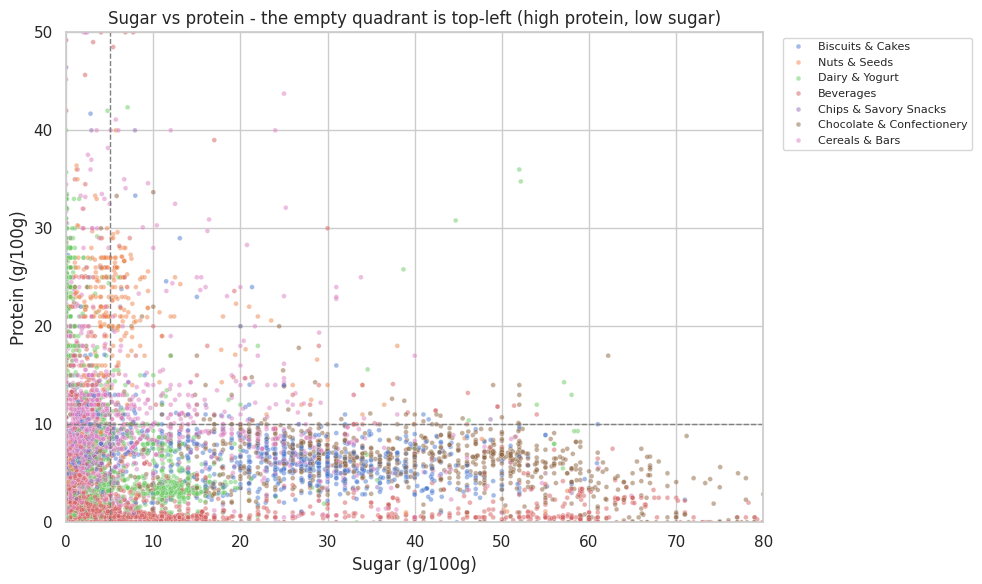

Only 17.3% of all snack products sit in the high-protein / low-sugar quadrant.


In [ ]:
PROTEIN_HI = 10   # g protein / 100g considered "high protein"
SUGAR_LO = 5      # g sugar / 100g considered "low sugar"
df["healthy_quadrant"] = (df["proteins_100g"] >= PROTEIN_HI) & (df["sugars_100g"] <= SUGAR_LO)

# Sample for a readable scatter (full set is plotted in the dashboard interactively).
plot_df = df.sample(min(8000, len(df)), random_state=1)
fig, ax = plt.subplots()
sns.scatterplot(data=plot_df, x="sugars_100g", y="proteins_100g",
                hue="primary_category", s=12, alpha=0.5, ax=ax)
ax.axhline(PROTEIN_HI, color="grey", linestyle="--", lw=1)
ax.axvline(SUGAR_LO, color="grey", linestyle="--", lw=1)
ax.set_xlim(0, 80)
ax.set_ylim(0, 50)
ax.set_title("Sugar vs protein - the empty quadrant is top-left (high protein, low sugar)")
ax.set_xlabel("Sugar (g/100g)")
ax.set_ylabel("Protein (g/100g)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

healthy_share = df["healthy_quadrant"].mean() * 100
print(f"Only {healthy_share:.1f}% of all snack products sit in the high-protein / low-sugar quadrant.")

## 4. Recommendation

For each bucket we measure size, typical sugar/protein, and how few products already serve the
healthy quadrant. The biggest opportunity is a large, sugar-heavy category with almost no
high-protein / low-sugar options.

In [ ]:
cat = (df.groupby("primary_category")
         .agg(products=("code", "count"),
              median_sugar=("sugars_100g", "median"),
              median_protein=("proteins_100g", "median"),
              healthy_share=("healthy_quadrant", "mean"))
         .reset_index())
cat["healthy_share"] = (cat["healthy_share"] * 100).round(1)
# Opportunity = big category, lots of sugar, few healthy options.
cat["opportunity_score"] = (cat["products"] / cat["products"].max() * 50
                            + cat["median_sugar"]
                            - cat["healthy_share"])
cat = cat.sort_values("opportunity_score", ascending=False)
cat.round(1)

In [ ]:
target = cat.iloc[0]
p_target = int(df[df["primary_category"] == target["primary_category"]]["proteins_100g"]
               .quantile(0.9))
print("RECOMMENDATION")
print(f"The biggest market opportunity is in {target['primary_category']}, "
      f"specifically targeting products with at least {max(p_target, PROTEIN_HI)}g protein "
      f"and less than {SUGAR_LO}g sugar per 100g.")
print(f"\nWhy: it holds {int(target['products']):,} products with a median sugar of "
      f"{target['median_sugar']:.1f}g, yet only {target['healthy_share']:.1f}% already meet the "
      f"high-protein / low-sugar bar.")

RECOMMENDATION
The biggest market opportunity is in Chocolate & Confectionery, specifically targeting products with at least 10g protein and less than 5g sugar per 100g.

Why: it holds 26,908 products with a median sugar of 38.0g, yet only 2.1% already meet the high-protein / low-sugar bar.


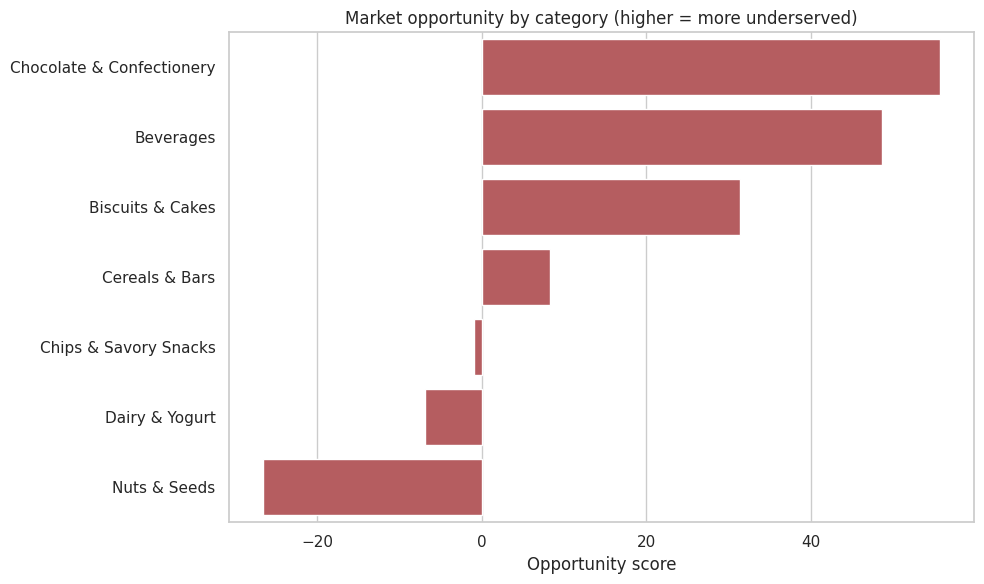

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=cat, y="primary_category", x="opportunity_score", color="#C44E52", ax=ax)
ax.set_title("Market opportunity by category (higher = more underserved)")
ax.set_xlabel("Opportunity score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Bonus: hidden-gem protein sources

Among the products that already hit high protein, which protein sources show up most in the
ingredient lists? That tells the manufacturer what to formulate with.

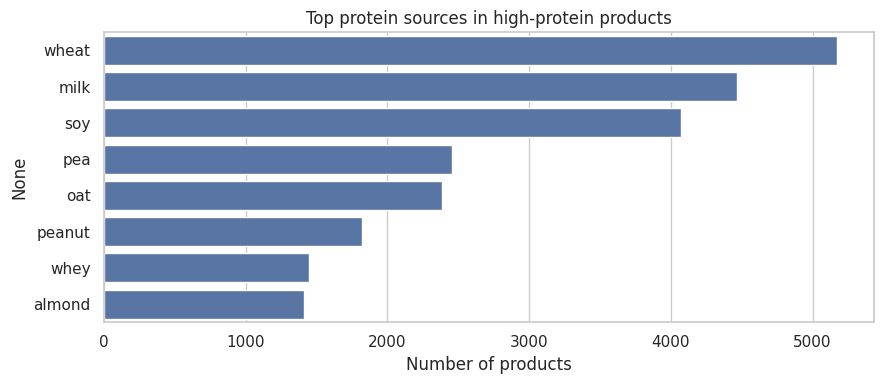

In [ ]:
SOURCES = ["whey", "milk", "soy", "soya", "pea", "peanut", "almond", "egg",
           "casein", "wheat", "gelatin", "lentil", "chickpea", "hazelnut", "oat"]
hi_protein = df[df["proteins_100g"] >= PROTEIN_HI].dropna(subset=["ingredients_text"])
text = hi_protein["ingredients_text"].str.lower()
counts = {s: text.str.contains(rf"\b{s}", regex=True).sum() for s in SOURCES}
top = pd.Series(counts).sort_values(ascending=False).head(8)
print("Most common protein sources in high-protein products:")
print(top)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=top.values, y=top.index, color="#4C72B0", ax=ax)
ax.set_title("Top protein sources in high-protein products")
ax.set_xlabel("Number of products")
plt.tight_layout()
plt.show()

## Candidate's choice: the Sugar Trap index

A single number per category that captures the "trap": how sugar-dominant the supply is
relative to protein. We define `sugar_trap = median_sugar / (median_protein + 1)`. A high value
means the shelf is full of sugary, low-protein products - the clearest signal of an unmet
healthy-snacking need, and a sharper ranking than raw sugar alone.

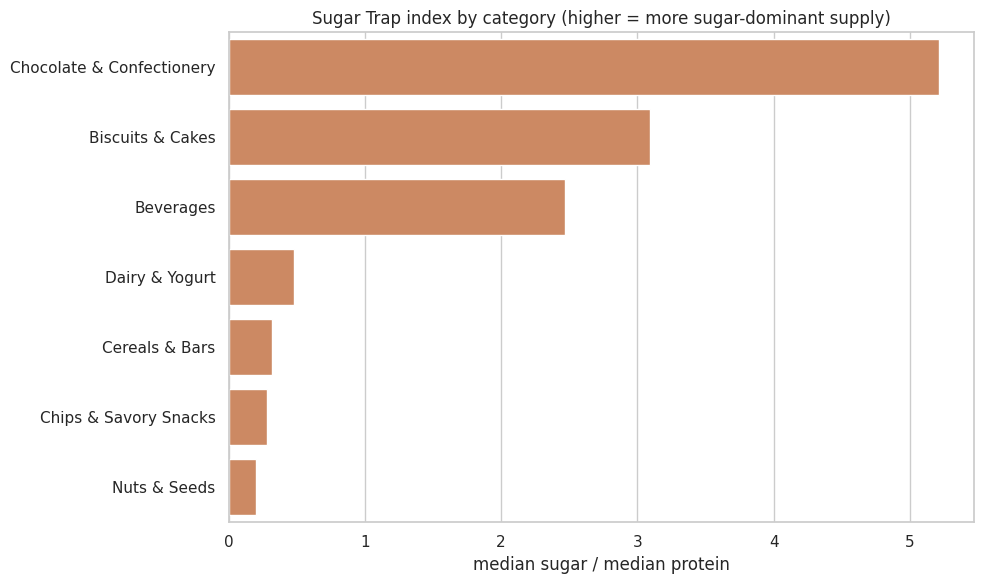

In [ ]:
cat["sugar_trap"] = (cat["median_sugar"] / (cat["median_protein"] + 1)).round(2)
trap = cat.sort_values("sugar_trap", ascending=False)[
    ["primary_category", "median_sugar", "median_protein", "sugar_trap", "healthy_share"]]
print(trap.to_string(index=False))

fig, ax = plt.subplots()
sns.barplot(data=trap, y="primary_category", x="sugar_trap", color="#DD8452", ax=ax)
ax.set_title("Sugar Trap index by category (higher = more sugar-dominant supply)")
ax.set_xlabel("median sugar / median protein")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Export the cleaned dataset for the dashboard

In [ ]:
export_cols = ["code", "product_name", "primary_category",
               "sugars_100g", "proteins_100g", "fiber_100g", "fat_100g",
               "energy-kcal_100g", "healthy_quadrant"]
clean = df[export_cols].rename(columns={"energy-kcal_100g": "energy_kcal_100g"})
# Cap the product-level table so the committed parquet stays small.
if len(clean) > 150_000:
    clean = clean.sample(150_000, random_state=1).reset_index(drop=True)

os.makedirs("data/processed", exist_ok=True)
out = "data/processed/products_clean.parquet"
clean.to_parquet(out, index=False)
print(f"wrote {out} ({len(clean):,} rows, {os.path.getsize(out)/1e6:.1f} MB)")

try:
    from google.colab import files  # type: ignore
    files.download(out)
except Exception:
    print("Not on Colab - parquet is in the local data/processed/ folder.")

## Key findings

In [ ]:
print("products analysed:", f"{len(df):,}")
print("categories:", df["primary_category"].nunique())
print("healthy-quadrant share overall:", f"{healthy_share:.1f}%")
print("top opportunity category:", target["primary_category"])
print("highest sugar-trap category:", trap.iloc[0]["primary_category"],
      f"(index {trap.iloc[0]['sugar_trap']})")

products analysed: 218,092
categories: 7
healthy-quadrant share overall: 17.3%
top opportunity category: Chocolate & Confectionery
highest sugar-trap category: Chocolate & Confectionery (index 5.21)
